# **Data Cleaning**

In [2]:
import pandas as pd 
import numpy as np
import emoji
from sklearn.model_selection import train_test_split
from langdetect import detect, LangDetectException
import re
import matplotlib.pyplot as plt
import seaborn as sns

## **1. Merge two raw data into one data**

In [3]:
raw_df1 = pd.read_csv("data/tatoeba.csv")
raw_df1.head(5)

,English,Vietnamese
0,Hmm?,Hử?
1,Translate.,Dịch.
2,Faster.,Nhanh hơn.
3,Kiss!,Hôn đi!
4,Please...,Đi mà...


In [4]:
raw_df1.shape

(15861, 2)

In [5]:
raw_df2 = pd.read_csv("data/QED.csv")
raw_df2.head(5)

,English,Vietnamese
0,"It should print 12, and 3 plus 4 plus 5 with a...","Nó sẽ in ra 12, và 3 + 4 + 5 với tất cả các kh..."
1,This might have been different from what you e...,Điều này có lẽ khác với những gì bạn mong đợi.
2,We didn't use quotation marks here.,Chúng ta không sử dụng dấu ngoặc kép ở đây.
3,The quotation marks mark literal text.,Dấu ngoặc kép dùng để đánh dấu văn bản.
4,"If we use quotes, it means that we want to wri...","Nếu ta sử dụng ngoặc kép, điều đó có nghĩa là ..."


In [6]:
raw_df2.shape

(338024, 2)

In [7]:
df = pd.concat([raw_df1, raw_df2], axis=0)
df.head(5)

,English,Vietnamese
0,Hmm?,Hử?
1,Translate.,Dịch.
2,Faster.,Nhanh hơn.
3,Kiss!,Hôn đi!
4,Please...,Đi mà...


In [8]:
df.shape

(353885, 2)

## **2. Data Cleaning**

In [9]:
def clean_text(text, lang='en'):
    """
    Clean and validate language of input text.
    - Lowercase text
    - Remove emojis
    - Remove all punctuation
    - Normalize whitespace
    - Return "" if language detection does not match target language
    """
    if not isinstance(text, str) or text.strip() == "":
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove emojis
    for em in emoji.emoji_list(text):
        text = text.replace(em['emoji'], '')

    # Remove all punctuation/special characters (keep letters, digits, spaces, hyphen)
    if lang == 'en':
        text = re.sub(r"[^a-z0-9\s\-]", '', text)
    elif lang == 'vi':
        text = re.sub(r"[^a-zA-Z0-9\sàáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệ"
                      r"ìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữự"
                      r"ỳýỷỹỵđ\s\-]", '', text)

    # Normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Language detection
    try:
        if detect(text) != lang:
            return ""
    except LangDetectException:
        return ""

    return text


In [10]:
df['English'] = df['English'].apply(lambda x: clean_text(x, lang='en'))
df['Vietnamese'] = df['Vietnamese'].apply(lambda x: clean_text(x, lang='vi'))

In [11]:
df.head(10)

,English,Vietnamese
0,,hử
1,,dịch
2,,nhanh hơn
3,,hôn đi
4,please,đi mà
5,coffee,cà phê
6,,ôi chúa ơi
7,enough,đủ rồi
8,,tuyệt vời
9,,


In [12]:
number_duplated_rows = df.duplicated(keep="first").sum()
print(f"duplicated rows:{number_duplated_rows}")

duplicated rows:36983


In [13]:
def empty_or_whitespace_ratio(series):
    return np.mean(series.str.strip() == "")

eng_empty_or_whitespace_ratio = empty_or_whitespace_ratio(df["English"])
vie_empty_or_whitespace_ratio = empty_or_whitespace_ratio(df["Vietnamese"])
print(f"English: {eng_empty_or_whitespace_ratio}, Vietnamese: {vie_empty_or_whitespace_ratio}")

English: 0.14470802661881685, Vietnamese: 0.033010723822710766


Empty or whitespace ratios which are visuallized above, leads to the decision to remove these records.

In [14]:
df = df[(df["English"].str.strip() != "") & (df["Vietnamese"].str.strip() != "")]

In [15]:
df.shape

(298597, 2)

Text(0.5, 1.0, 'English Length Distribution')

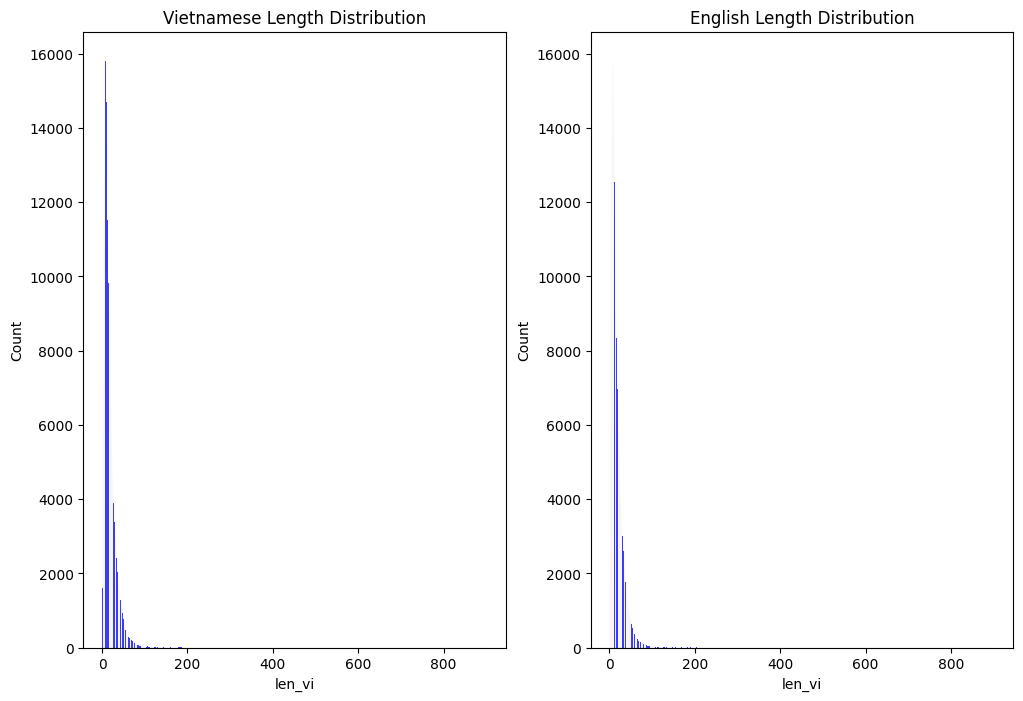

In [16]:
df["len_vi"] = df["Vietnamese"].apply(lambda x: len(x.split()))
df["len_en"] = df["English"].apply(lambda x: len(x.split()))


# visualize
fig, axes = plt.subplots(1, 2 , figsize= (12,8))


sns.histplot(data= df["len_vi"], color= "blue", ax= axes[0])
axes[0].set_title("Vietnamese Length Distribution")

sns.histplot(data= df["len_vi"], color= "blue", ax= axes[1])

axes[1].set_title("English Length Distribution")

Text(0.5, 1.0, 'English Length Distribution')

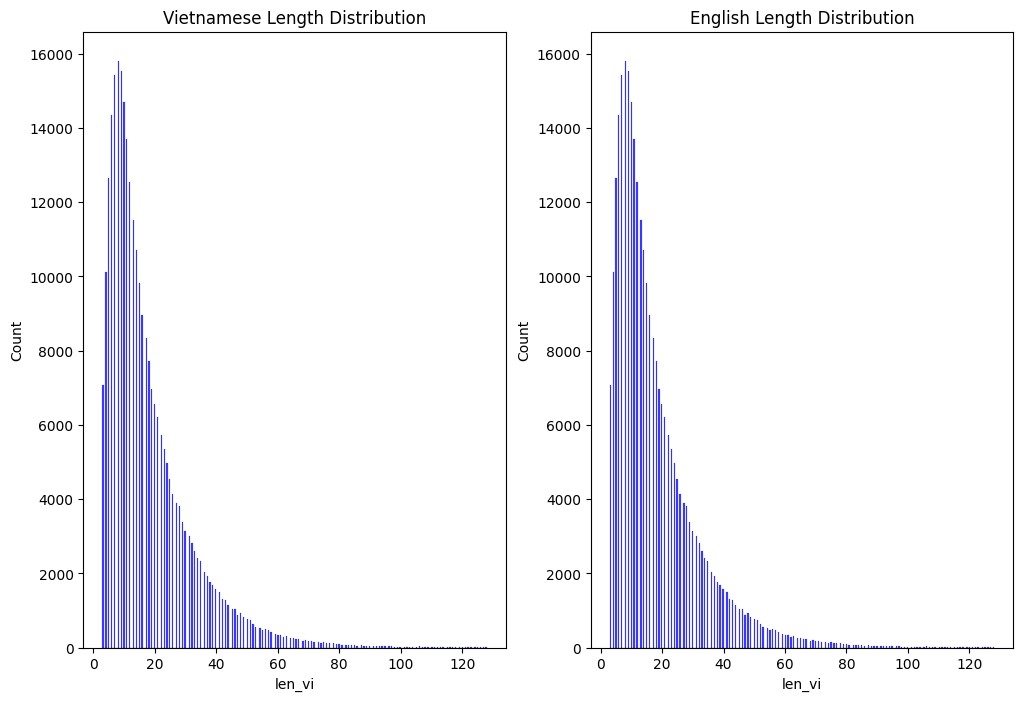

In [17]:
cleaned_data = df[(df['len_vi'] <= 128) & (df['len_vi'] >= 3)]

# visualize
fig, axes = plt.subplots(1, 2 , figsize= (12,8))


sns.histplot(data  = cleaned_data["len_vi"], color= "blue", ax= axes[0])
axes[0].set_title("Vietnamese Length Distribution")

sns.histplot(data =  cleaned_data["len_vi"], color= "blue", ax= axes[1])

axes[1].set_title("English Length Distribution")

In [18]:
cleaned_data.shape

(290782, 4)

In [19]:
train, test = train_test_split(cleaned_data, test_size= 0.2, random_state= 31072004)

In [20]:
train.shape

(232625, 4)

In [21]:
test.shape

(58157, 4)

In [ ]:
cleaned_data.to_csv("data/translation_dataset.csv", index= False)

train.to_csv("data/train.csv", index= False)
test.to_csv("data/test.csv", index= False)